<ipython-input-12-eca46a36b5f6>:24: RuntimeWarning: divide by zero encountered in log10
  plt.plot(n_values, np.log10(errors[i]), label=f'x={x}')


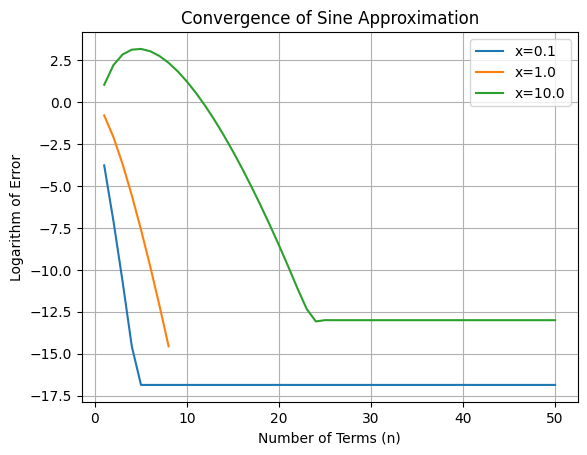

In [12]:
import math
from math import factorial
import numpy as np
import matplotlib.pyplot as plt
#Q1
def sine(x,n):
  precision = n #how many terms are added in the power series
  result = x
  for i in range(1,precision): #set the loop statring from one since we add x in the result so we don't need to start from 0
    if i % 2 ==1:
      result = result - (pow(x,2*i+1))/(math.factorial(2*i+1))  #if the index is odd, the sign is minus
    if i % 2 ==0:
      result = result + (pow(x,2*i+1))/(math.factorial(2*i+1))  #if the index is even, the sign is plus
  return result
x_values = [0.1, 1.0, 10.0]  # Test with small, moderate, and large x values
n_values = list(range(1, 51))
# Calculate the errors for different x values and n values
errors = []
for x in x_values:
    errors_x = [abs(math.sin(x) - sine(x, n)) for n in n_values]
    errors.append(errors_x)
# Plot the logarithm of errors for each x value
for i, x in enumerate(x_values):
    plt.plot(n_values, np.log10(errors[i]), label=f'x={x}')

plt.xlabel('Number of Terms (n)')
plt.ylabel('Logarithm of Error')
plt.legend()
plt.title('Convergence of Sine Approximation')
plt.grid()
plt.show()


<ipython-input-14-fac1d28ca25c>:27: RuntimeWarning: divide by zero encountered in log10
  plt.plot(n_values, np.log10(errors[i]), label=f'x={x}')


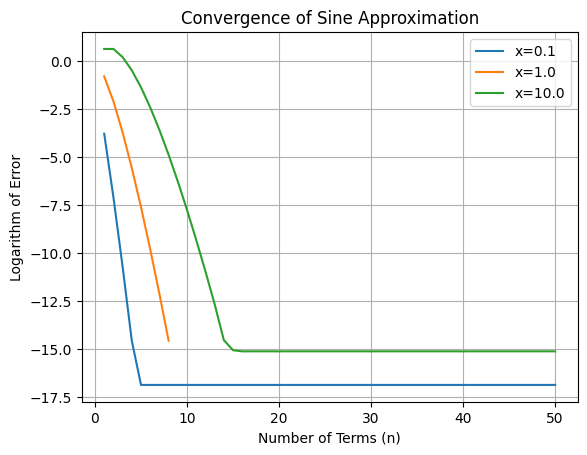

In [14]:
#Q2
import math
from math import factorial
import numpy as np
import matplotlib.pyplot as plt
#Q1
def sine(x,n):
  #argument reduction : change the large number into the interval of [0,2pi]
  y = x % (math.pi*2)
  precision = n #how many terms are added in the power series
  result = y
  for i in range(1,precision): #set the loop statring from one since we add x in the result so we don't need to start from 0
    if i % 2 ==1:
      result = result - (pow(y,2*i+1))/(math.factorial(2*i+1))  #if the index is odd, the sign is minus
    if i % 2 ==0:
      result = result + (pow(y,2*i+1))/(math.factorial(2*i+1))  #if the index is even, the sign is plus
  return result
x_values = [0.1, 1.0, 10.0]  # Test with small, moderate, and large x values
n_values = list(range(1, 51))
# Calculate the errors for different x values and n values
errors = []
for x in x_values:
    errors_x = [abs(math.sin(x) - sine(x, n)) for n in n_values]
    errors.append(errors_x)
# Plot the logarithm of errors for each x value
for i, x in enumerate(x_values):
    plt.plot(n_values, np.log10(errors[i]), label=f'x={x}')

plt.xlabel('Number of Terms (n)')
plt.ylabel('Logarithm of Error')
plt.legend()
plt.title('Convergence of Sine Approximation')
plt.grid()
plt.show()

<ipython-input-27-bcda0982c8bd>:40: RuntimeWarning: divide by zero encountered in log10
  plt.plot(n_values, np.log10(errors[i]), label=f'x={x}')


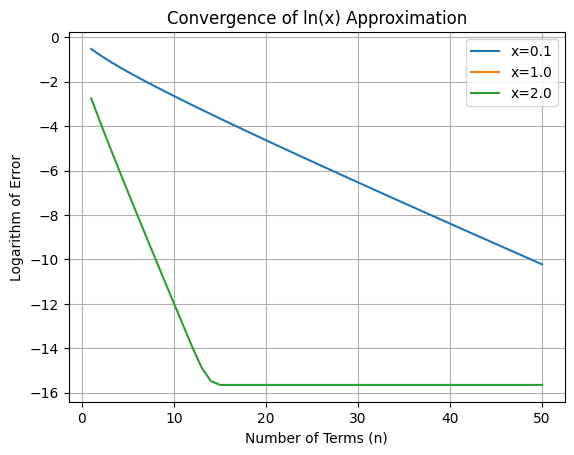

math.log time is 0.00010180473327636719 power series time is  2.384185791015625e-05 the alternative time is 1.811981201171875e-05


In [27]:
#Q3
import time
import math
import numpy as np
import matplotlib.pyplot as plt

def compute_ln_taylor(x, n):
  #solve the case where x <0
    if x <= 0:
        return float('-inf')
    #solve for int y where x= (1+y)/(1-y)
    y = (x-1)/(x+1)
    result = y
    for i in range(1, n + 1):
        result += y**(2*i+1)/(2*i+1)
    return 2*result

def alternative_ln(x,n):
  i=0
  while x>=2:
    x=math.sqrt(x)
    i=i+1
  z=x-1
  for j in range(1, n):
    z=z/(1+math.sqrt(1+z))
  return pow(2,i)*z


x_values = [0.1, 1.0, 2.0]  # Test with small, moderate, and large x values
n_values = list(range(1, 51))  # Number of terms in the series

# Calculate the errors for different x values and n values
errors = []
for x in x_values:
    errors_x = [abs(math.log(x) - compute_ln_taylor(x, n)) for n in n_values]
    errors.append(errors_x)

# Plot the logarithm of errors for each x value
for i, x in enumerate(x_values):
    plt.plot(n_values, np.log10(errors[i]), label=f'x={x}')

plt.xlabel('Number of Terms (n)')
plt.ylabel('Logarithm of Error')
plt.legend()
plt.title('Convergence of ln(x) Approximation')
plt.grid()
plt.show()


#Q4
def ln_time(x, n):
  #solve the case where x <0
    if x <= 0:
        return float('-inf')
    start_time = time.time()
    #solve for int y where x= (1+y)/(1-y)
    y = (x-1)/(x+1)
    result = y
    for i in range(1, n + 1):
        result += y**(2*i+1)/(2*i+1)
    end_time = time.time()
    elapsed_time = end_time - start_time
    return elapsed_time


def alternative_ln_time(x,n):
  start_time = time.time()
  i=0
  while x>=2:
    x=math.sqrt(x)
    i=i+1
  z=x-1
  for j in range(1, n):
    z=z/(1+math.sqrt(1+z))
  end_time = time.time()
  elapsed_time = end_time - start_time
  return elapsed_time

#record the start time
start_time = time.time()
result1 = math.log(3)
# Record the end time
end_time = time.time()
# Calculate the elapsed time
elapsed_time = end_time - start_time

result1_= ln_time(3, 51)
result2= alternative_ln_time(3,51)
#print out the time difference
print("math.log time is",elapsed_time,"power series time is ", result1_, "the alternative time is", result2)

In [29]:
#part 2
#Q1
import math

# Goldschmidt's method for square root calculation
def goldschmidt_sqrt(x, iterations):
    guess = math.sqrt(x)
    for i in range(0,iterations):
      y= 0.5*(guess+x/guess) #helper y
      guess = guess*(y/guess) #iteration on A
    return guess



# Heron's method for square root calculation
def heron_sqrt(x, iterations):
    guess = math.sqrt(x)
    for i in range(0,iterations):
      guess = 0.5*(guess+x/guess) #iteration on A
    return guess

result1= goldschmidt_sqrt(23, 10)
result2=heron_sqrt(23, 10)
result3= math.sqrt(23)
print("GD:",result1, "Heron:",result2, "math:",result3)



GD: 4.795831523312719 Heron: 4.795831523312719 math: 4.795831523312719


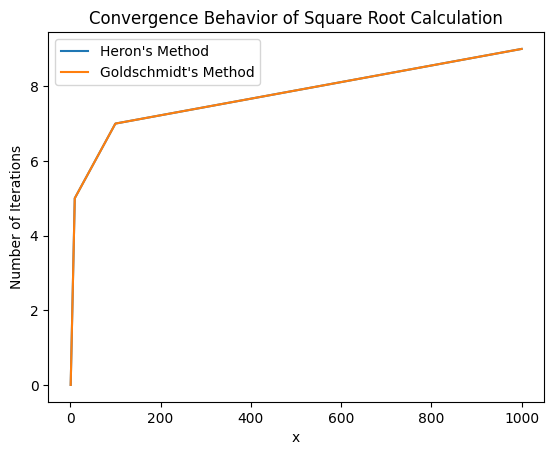

In [28]:
#Q1 experiment that illustrate the self-correcting behaviour of Heron's method, and the opposite behaviour of Goldschmidt's method.
import matplotlib.pyplot as plt

# Define Heron's Method
def heron_sqrt(x, initial_guess=1.0, tolerance=1e-6):
    guess = initial_guess
    iterations = 0
    while abs(guess * guess - x) > tolerance: #if the error is larger than 1e-6, constantly loop to generate update of the sqrt(x)=A
        guess = 0.5 * (guess + x / guess)
        iterations += 1
    return iterations

# Define Goldschmidt's Method
def goldschmidt_sqrt(x, initial_guess=1.0, tolerance=1e-6):
    guess = initial_guess
    iterations = 0
    while abs(guess * guess - x) > tolerance:
        y = (guess + x / guess) / 2
        guess = guess * (y / guess)
        iterations += 1
    return iterations

x_values = [1, 10, 100, 1000]  # Example x values
heron_iterations = []
goldschmidt_iterations = []

for x in x_values:
    heron_iterations.append(heron_sqrt(x))
    goldschmidt_iterations.append(goldschmidt_sqrt(x))

# Plot the results
plt.plot(x_values, heron_iterations, label="Heron's Method")
plt.plot(x_values, goldschmidt_iterations, label="Goldschmidt's Method")
plt.xlabel('x')
plt.ylabel('Number of Iterations')
plt.legend()
plt.title('Convergence Behavior of Square Root Calculation')
plt.show()

as above we could see that Goldschmisdt methods is converging while the Heron method is self correcting so that is does not converges.

Linearly convergent method did not converge.
Quadratically convergent method result: -3.1830630119333634 (converged in 18 iterations)


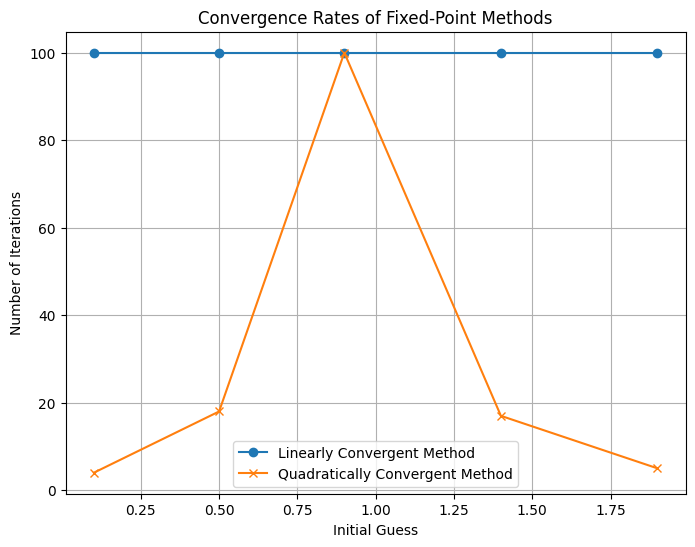

In [8]:
#Q2
import math
import matplotlib.pyplot as plt

#from Q1 get sine function
def sine(x,n):
  #argument reduction : change the large number into the interval of [0,2pi]
  y = x % (math.pi*2)
  precision = n #how many terms are added in the power series
  result = y
  for i in range(1,precision): #set the loop statring from one since we add x in the result so we don't need to start from 0
    if i % 2 ==1:
      result = result - (pow(y,2*i+1))/(math.factorial(2*i+1))  #if the index is odd, the sign is minus
    if i % 2 ==0:
      result = result + (pow(y,2*i+1))/(math.factorial(2*i+1))  #if the index is even, the sign is plus
  return result
#from Q3 get log function
def compute_ln_taylor(x, n):
  #solve the case where x <0
    if x <= 0:
        return float('-inf')
    #solve for int y where x= (1+y)/(1-y)
    y = (x-1)/(x+1)
    result = y
    for i in range(1, n + 1):
        result += y**(2*i+1)/(2*i+1)
    return 2*result
# Linearly convergent method
def linear_fixed_point_iteration(initial_guess, tolerance, max_iterations):
    x = initial_guess
    iterations = 0
    while iterations < max_iterations:
        x_next = compute_ln_taylor(sine(x,50),n=50)
        if abs(x_next - x) < tolerance:
            return x_next, iterations
        x = x_next
        iterations += 1
    return None, max_iterations

# Quadratically convergent method (Newton's method)
def newton_method(initial_guess, tolerance, max_iterations):
    x = initial_guess
    iterations = 0
    while iterations < max_iterations:
        f_x = math.sin(x) - math.exp(x)
        df_x = math.cos(x) - math.exp(x)
        x_next = x - f_x / df_x
        if abs(x_next - x) < tolerance:
            return x_next, iterations
        x = x_next
        iterations += 1
    return None, max_iterations

# Test the methods with initial guesses and tolerances
initial_guess = 0.5
tolerance = 1e-8
max_iterations = 100 #inictialized a raletively larged initial guess of the max iteration number

result_linear, iterations_linear = linear_fixed_point_iteration(initial_guess, tolerance, max_iterations)
result_newton, iterations_newton = newton_method(initial_guess, tolerance, max_iterations)

if result_linear:
    print(f"Linearly convergent method result: {result_linear} (converged in {iterations_linear} iterations)")
else:
    print("Linearly convergent method did not converge.")

if result_newton:
    print(f"Quadratically convergent method result: {result_newton} (converged in {iterations_newton} iterations)")
else:
    print("Quadratically convergent method did not converge.")

# Test the methods with different initial guesses and record convergence rates
initial_guesses = [0.1, 0.5, 0.9, 1.4, 1.9]
tolerance = 1e-8
max_iterations = 100

results_linear = []
results_newton = []

for initial_guess in initial_guesses:
    result_linear, iterations_linear = linear_fixed_point_iteration(initial_guess, tolerance, max_iterations)
    results_linear.append(iterations_linear)

    result_newton, iterations_newton = newton_method(initial_guess, tolerance, max_iterations)
    results_newton.append(iterations_newton)

# Create a plot to visualize convergence rates
plt.figure(figsize=(8, 6))
plt.plot(initial_guesses, results_linear, marker='o', label='Linearly Convergent Method')
plt.plot(initial_guesses, results_newton, marker='x', label="Quadratically Convergent Method")
plt.xlabel('Initial Guess')
plt.ylabel('Number of Iterations')
plt.title('Convergence Rates of Fixed-Point Methods')
plt.legend()
plt.grid(True)
plt.show()


Solution: y(cos 20 degree) ≈ 0.9396926207859084
Number of iterations: 4
Derivative is close to zero. Adjust your initial guess.


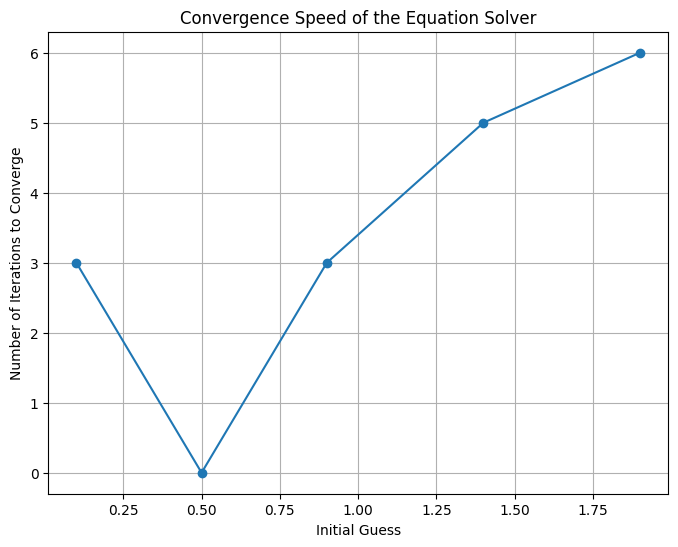

sin(20 degrees) ≈ 0.34202014332566866
sin(20 degree) of Q1 is 0.34202014332566877


In [25]:
#Q3
import math
import matplotlib.pyplot as plt
def solve_cubic_equation(a, initial_guess, tolerance, max_iterations):
    y = initial_guess
    iterations = 0
    while iterations < max_iterations:
        f_y = 4 * y ** 3 - 3 * y - a
        f_prime_y = 12 * y ** 2 - 3
        if abs(f_prime_y) < 1e-12:  # Tolerance for derivative close to zero
            print("Derivative is close to zero. Adjust your initial guess.")
            return None, iterations
        y_next = y - f_y / f_prime_y
        if abs(y_next - y) < tolerance:
            return y_next, iterations
        y = y_next
        iterations += 1
    return None, max_iterations

# Set the equation parameters
a = math.cos(math.radians(60))  #set a = cos(60 degree), therefore the calculation result of y is cos(20 degree)
initial_guess = 1.2
tolerance = 1e-8
max_iterations = 100

# Solve the equation
result, iterations = solve_cubic_equation(a, initial_guess, tolerance, max_iterations)

if result is not None:
    print(f"Solution: y(cos 20 degree) ≈ {result}")
    print(f"Number of iterations: {iterations}")
else:
    print("The method did not converge.")

#test the convergence speed
# Vary the initial guesses and record the number of iterations
initial_guesses = [0.1, 0.5, 0.9, 1.4, 1.9]

results = []
for initial_guess in initial_guesses:
    result, iterations = solve_cubic_equation(a, initial_guess, tolerance, max_iterations)
    results.append(iterations)

# Create a plot to visualize the convergence speed
plt.figure(figsize=(8, 6))
plt.plot(initial_guesses, results, marker='o')
plt.xlabel('Initial Guess')
plt.ylabel('Number of Iterations to Converge')
plt.title('Convergence Speed of the Equation Solver')
plt.grid(True)
plt.show()


#sine x from question 1
#Q1
def sine(x,n):
  precision = n #how many terms are added in the power series
  result = x
  for i in range(1,precision): #set the loop statring from one since we add x in the result so we don't need to start from 0
    if i % 2 ==1:
      result = result - (pow(x,2*i+1))/(math.factorial(2*i+1))  #if the index is odd, the sign is minus
    if i % 2 ==0:
      result = result + (pow(x,2*i+1))/(math.factorial(2*i+1))  #if the index is even, the sign is plus
  return result

sin_20_Q1= sine(math.radians(20),50)
# Calculate sin(20 degrees) using the obtained y=cos(20 degrees) value, use the formula that sin^2+cos^2=1
sin_20_degrees = math.sqrt(1 - result ** 2)
print(f"sin(20 degrees) ≈ {sin_20_degrees}")
print("sin(20 degree) of Q1 is", sin_20_Q1)